# justviz + dr2d Demo

GPU-accelerated scatter and bar charts via the dr2d Python binding.

In [1]:
import numpy as np
from PIL import Image
from IPython.display import display
from justviz import scatter, bar

In [7]:
!uv pip install pandas seaborn matplotlib datashader

Using Python 3.12.3 environment at: /home/skrsan/Documents/Projects/viz_primitive/.venv
Resolved 28 packages in 630ms                                        
Prepared 9 packages in 14.70s                                            
Installed 10 packages in 22ms                               
 + colorcet==3.1.0
 + datashader==0.19.0
 + llvmlite==0.46.0
 + multipledispatch==1.0.0
 + numba==0.64.0
 + param==2.3.2
 + pyct==0.6.0
 + scipy==1.17.1
 + toolz==1.1.0
 + xarray==2026.2.0


## 1. Basic Scatter Plot

scatter: 1,000 points, 800×600, render 194.5ms


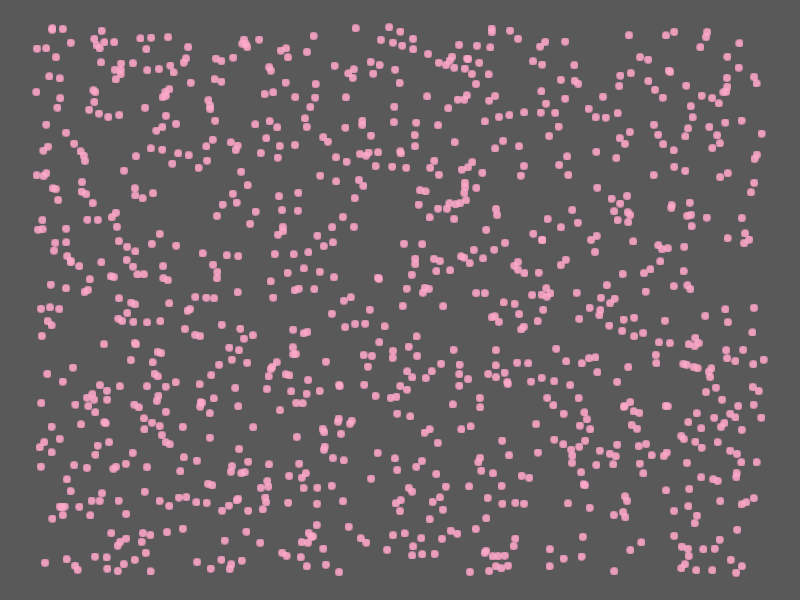

In [2]:
np.random.seed(42)
x = np.random.uniform(0, 100, 1000).astype(np.float32)
y = np.random.uniform(0, 100, 1000).astype(np.float32)

img = scatter(x, y, color=(1.0, 0.4, 0.6), size=4.0, opacity=0.8, width=800, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 2. Basic Bar Chart

bar: 8 bars, 800×600, render 125.6ms


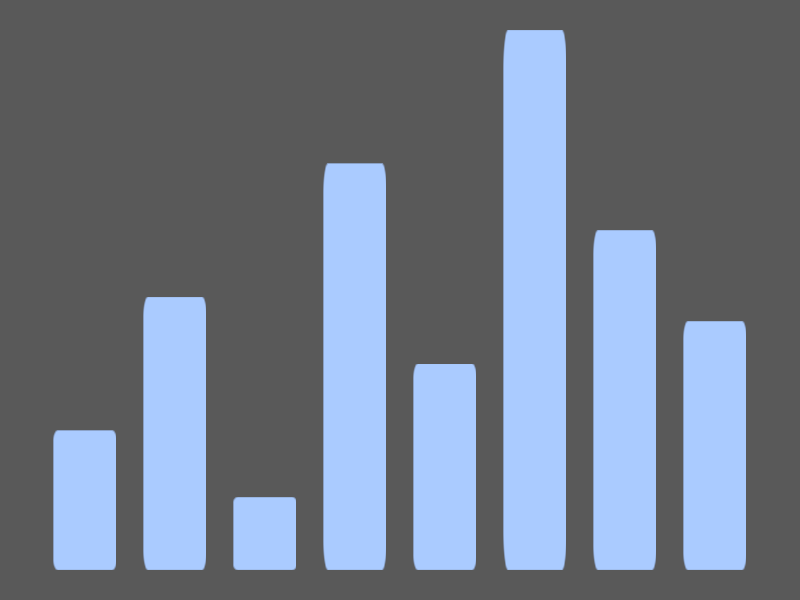

In [3]:
categories = np.arange(8, dtype=np.float32)
values = np.array([23, 45, 12, 67, 34, 89, 56, 41], dtype=np.float32)

img = bar(categories, values, color=(0.4, 0.6, 1.0), bar_width=0.7, width=800, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 3. Multi-Layer Scatter (2 datasets, 1M points total)

Total points: 1,000,000
scatter: 1,000,000 points (2 layers), 1024×768, render 334.6ms


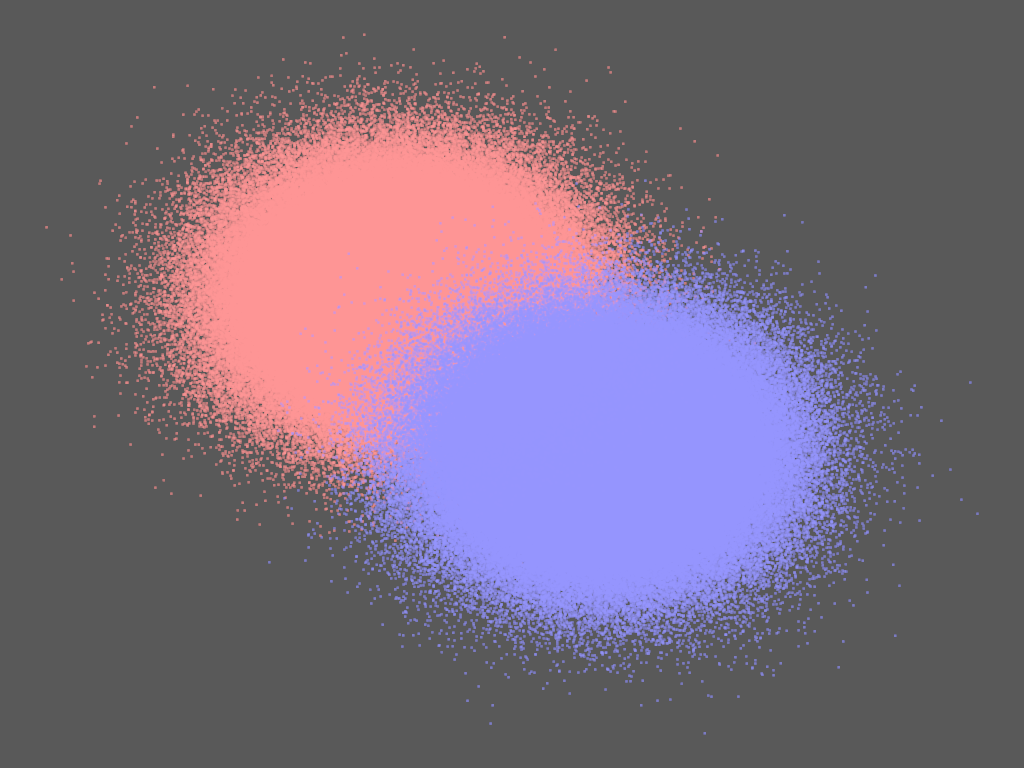

In [4]:
np.random.seed(123)

# Dataset A: 500K points, clustered bottom-left
x1 = np.random.normal(30, 15, 500_000).astype(np.float32)
y1 = np.random.normal(30, 15, 500_000).astype(np.float32)

# Dataset B: 500K points, clustered top-right
x2 = np.random.normal(70, 15, 500_000).astype(np.float32)
y2 = np.random.normal(70, 15, 500_000).astype(np.float32)

print(f"Total points: {len(x1) + len(x2):,}")

img = scatter(
    None, None,
    layers=[
        {"x": x1, "y": y1, "color": (1.0, 0.3, 0.3), "size": 1.5, "opacity": 0.5},
        {"x": x2, "y": y2, "color": (0.3, 0.3, 1.0), "size": 1.5, "opacity": 0.5},
    ],
    width=1024,
    height=768,
)
display(Image.fromarray(img, mode='RGBA'))

In [3]:
from justviz import scatter
import numpy as np

np.random.seed(42)
x = np.random.uniform(0, 100, 1000).astype(np.float32)
y = np.random.uniform(0, 100, 1000).astype(np.float32)

scatter(x, y, color=(1.0, 0.4, 0.6), size=4.0, interactive=True)


## 4. Load Parquet Data

If you have parquet files, you can load them directly via dr2d:

Loaded 10000 rows: price range [10.0, 200.0], volume range [100.2, 4999.6]
scatter: 10,000 points, 800×600, render 217.4ms


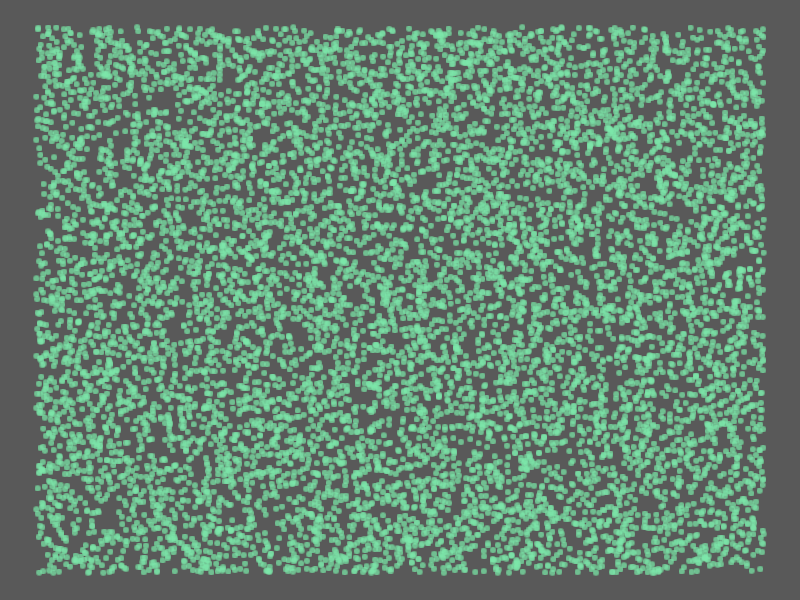

In [2]:
import dr2d

# Example: create a test parquet file, then load it
import pyarrow as pa
import pyarrow.parquet as pq

# Generate and save test data
np.random.seed(99)
table = pa.table({
    "price": np.random.uniform(10, 200, 10_000).astype(np.float32),
    "volume": np.random.uniform(100, 5000, 10_000).astype(np.float32),
})
pq.write_table(table, "/tmp/stress_test_10k.parquet")

# Load via dr2d
px, py_ = dr2d.load_parquet_columns("/tmp/stress_test_10k.parquet", "price", "volume")
print(f"Loaded {len(px)} rows: price range [{px.min():.1f}, {px.max():.1f}], volume range [{py_.min():.1f}, {py_.max():.1f}]")

img = scatter(px, py_, color=(0.2, 0.8, 0.4), size=3.0, opacity=0.6, width=800, height=600)
display(Image.fromarray(img, mode='RGBA'))

Total points: 1,000,000


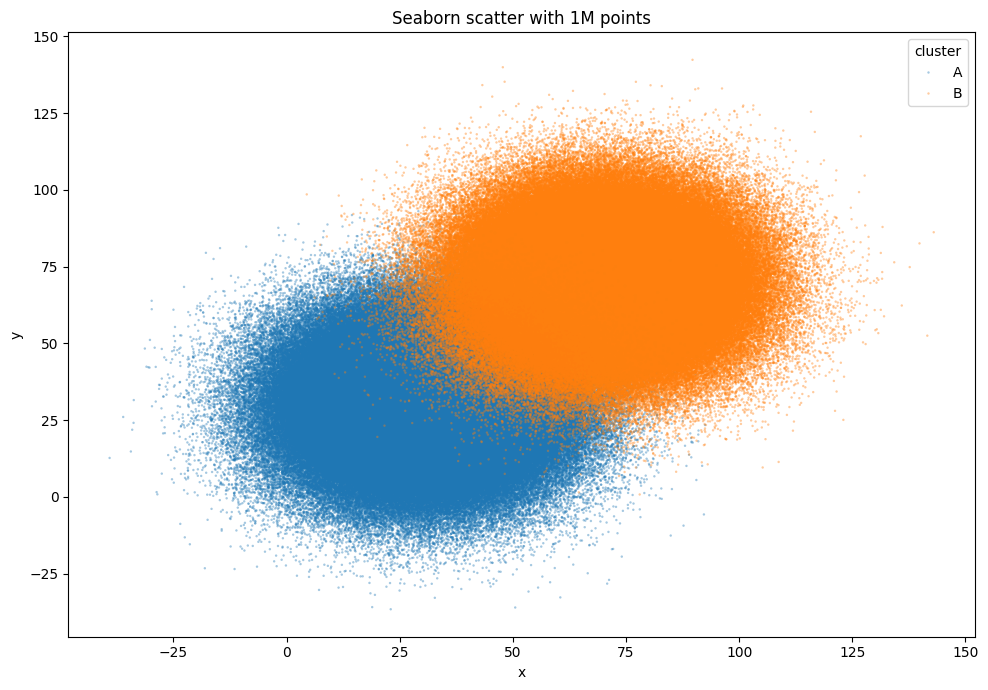

Render time: 3.54 seconds


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# For reproducibility
np.random.seed(123)

# 1,000,000 points: two clusters
n = 1_000_000
x1 = np.random.normal(30, 15, n // 2)
y1 = np.random.normal(30, 15, n // 2)
x2 = np.random.normal(70, 15, n // 2)
y2 = np.random.normal(70, 15, n // 2)

df = pd.DataFrame({
    "x": np.concatenate([x1, x2]).astype(np.float32),
    "y": np.concatenate([y1, y2]).astype(np.float32),
    "cluster": ["A"] * (n // 2) + ["B"] * (n // 2),
})

print(f"Total points: {len(df):,}")

# Measure render time
start = time.time()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="cluster",
    s=3,
    alpha=0.4,
    edgecolor=None,
    linewidth=0,
)

plt.title("Seaborn scatter with 1M points")
plt.tight_layout()
plt.show()

end = time.time()
print(f"Render time: {end - start:.2f} seconds")


Total points: 1,000,000


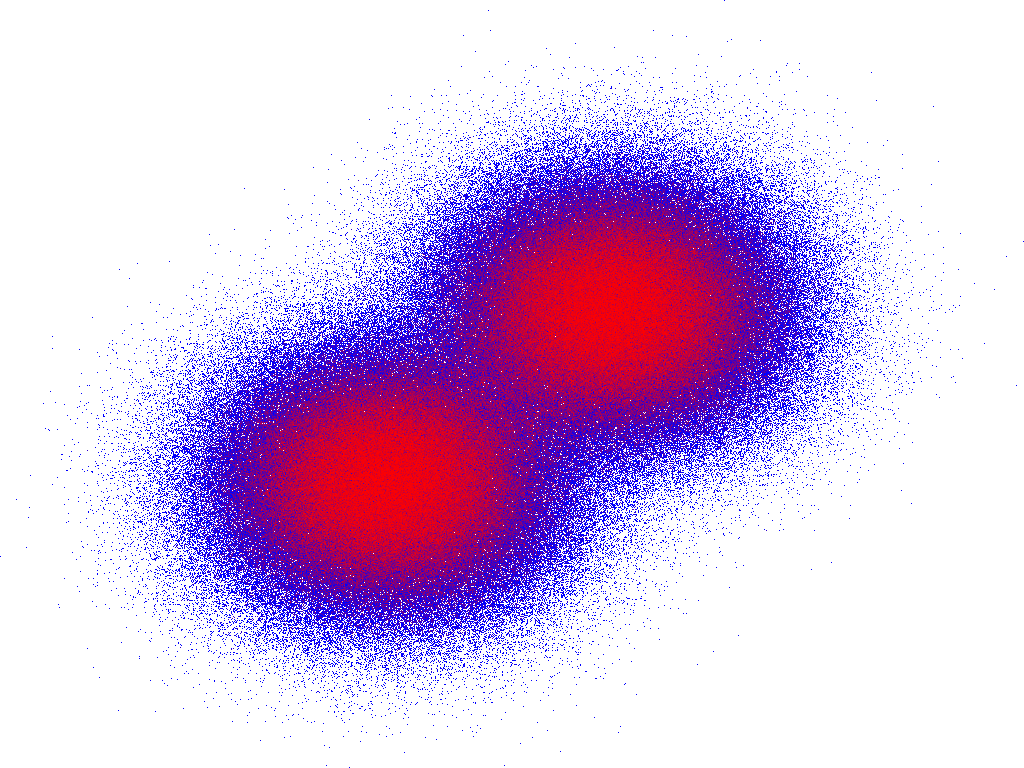

Render time: 0.025 seconds


In [3]:
import numpy as np
import pandas as pd
import datashader as ds
import datashader.transfer_functions as tf
from IPython.display import display
import time

np.random.seed(123)
n = 1_000_000

x1 = np.random.normal(30, 15, n // 2)
y1 = np.random.normal(30, 15, n // 2)
x2 = np.random.normal(70, 15, n // 2)
y2 = np.random.normal(70, 15, n // 2)

df = pd.DataFrame({
    "x": np.concatenate([x1, x2]).astype(np.float32),
    "y": np.concatenate([y1, y2]).astype(np.float32),
})

print(f"Total points: {len(df):,}")

canvas = ds.Canvas(plot_width=1024, plot_height=768)

start = time.time()
agg = canvas.points(df, "x", "y")
img = tf.shade(agg, cmap=["blue", "red"], how="eq_hist")
end = time.time()

display(img)
print(f"Render time: {end - start:.3f} seconds")
